# ETL fundos

In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import io
import zipfile

In [36]:
ano_mes = "202508"
caminho_fundos = Path("fundos")

caminho_fundos.mkdir(exist_ok=True)

# while ano_mes != "202608":
#     response = requests.get(rf"https://dados.cvm.gov.br/dados/FI/DOC/CDA/DADOS/cda_fi_{ano_mes}.zip", stream=True)

#     if response.status_code == 200:
#         with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
#             arquivos = zip_ref.namelist()
            
#             bloco_2_lista= [arq for arq in arquivos if "BLC_2" in arq]

#             if bloco_2_lista:
#                 bloco_2 = bloco_2_lista[0]
#                 zip_ref.extract(bloco_2, path=caminho_fundos)
#                 print(f"{bloco_2} baixado com sucesso\n")
#             else:
#                 print(f"nenhum arquivo relacionado foi encontrado em {ano_mes}")
#     else:
#         print(f"ERRO: falha no mÊs {ano_mes}: {response.status_code}")
#     ano_mes = datetime.strptime(ano_mes, "%Y%m")

#     ano_mes += relativedelta(months=1)

#     ano_mes = ano_mes.strftime('%Y%m')    
            

In [37]:
df_fundos_def = pd.DataFrame()
for fundo in caminho_fundos.glob('*.csv'):
    df_fundo = pd.read_csv(fundo, encoding='latin1', sep=';', dtype={'TP_NEGOC': str})
    cols_importantes = ["DT_COMPTC", "CNPJ_FUNDO_CLASSE", "DENOM_SOCIAL","TP_APLIC", "CNPJ_FUNDO_CLASSE_COTA", "TP_ATIVO","NM_FUNDO_CLASSE_SUBCLASSE_COTA", "VL_MERC_POS_FINAL"]
    df_fundo = df_fundo[cols_importantes]
    df_fundo = df_fundo[df_fundo['VL_MERC_POS_FINAL'] >= 100000]
    df_fundos_def = pd.concat([df_fundos_def, df_fundo], axis=0, ignore_index=True)

df_fundos_def.shape

(1203043, 8)

In [38]:
df_fundos_def['DT_COMPTC'].value_counts()

DT_COMPTC
2025-12-31    114015
2026-01-31    113864
2025-08-31    113772
2025-09-30    113732
2025-11-30    113015
2025-10-31    112823
2026-03-31    112360
2026-02-28    112030
2026-04-30    109511
2026-05-31     71343
2026-06-30     69870
2026-07-31     46708
Name: count, dtype: int64

# DF -> Grafo

In [39]:
import networkx as nx

In [40]:
df_fundos_def['DT_COMPTC'] = pd.to_datetime(df_fundos_def['DT_COMPTC'])

In [41]:
resultados_centralidade = []

"""
esse for irá "fatiar" o df pelos meses
a var mes vai guardar o "rótulo" do mês (ex: 05-2026)
dados_mes é o df em si
"""
for mes, dados_mes in df_fundos_def.groupby(df_fundos_def['DT_COMPTC'].dt.to_period('M')):

    # construção do grafo direcional
    G_mes = nx.from_pandas_edgelist(
        dados_mes,
        source='CNPJ_FUNDO_CLASSE',
        target="CNPJ_FUNDO_CLASSE_COTA",
        edge_attr="VL_MERC_POS_FINAL",
        create_using=nx.DiGraph()
    )

    # cálculo da centralidade de grau (métrica Efeito Manada)
    in_degree = nx.in_degree_centrality(G_mes)

    # Métrica de Risco de Contágio (Quem distribui investimento)
    out_degree = nx.out_degree_centrality(G_mes)

    # armazenando os resultados
    for cnpj in G_mes.nodes():
        resultados_centralidade.append({
            "Mes" : str(mes),
            "CNPJ" : cnpj,
            "Central_Grau_Ent" : in_degree[cnpj],
            "Central_Grau_Saida" : out_degree[cnpj]
        })

In [42]:
# matriz de features
df_features = pd.DataFrame(resultados_centralidade)
df_features = df_features.sort_values(by=['CNPJ', 'Mes']).reset_index(drop=True)

In [43]:
df_features.head(10)

,Mes,CNPJ,Central_Grau_Ent,Central_Grau_Saida
0,2025-08,00.068.305/0001-35,0.0,0.000038
1,2025-09,00.068.305/0001-35,0.0,0.000037
2,2025-10,00.068.305/0001-35,0.0,0.000038
3,2025-11,00.068.305/0001-35,0.0,0.000037
4,2025-12,00.068.305/0001-35,0.0,0.000037
5,2026-01,00.068.305/0001-35,0.0,0.000037
6,2026-02,00.068.305/0001-35,0.0,0.000038
7,2026-03,00.068.305/0001-35,0.0,0.000038
8,2026-04,00.068.305/0001-35,0.0,0.000038
9,2026-05,00.068.305/0001-35,0.0,0.000048


# Modelagem ML

In [44]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [45]:
# transformando meses em colunas
df_ml = df_features.pivot(index='CNPJ',
                          columns='Mes',
                          values=['Central_Grau_Ent', 'Central_Grau_Saida']).fillna(0)

df_ml.columns = [f"{metrica}_{mes}" for metrica, mes in df_ml.columns]

df_ml.shape

(30449, 24)

In [46]:
# separando os dfs para cada caso
colunas_manada = [col for col in df_ml.columns if 'Ent' in col]
colunas_contagio = [col for col in df_ml.columns if 'Saida' in col]

df_manada = df_ml[colunas_manada]
df_contagio = df_ml[colunas_contagio]
print(f"Tamanho DF de efeito manada: {len(df_manada)}")
print(f'Tamanho DF risco de contágio: {len(df_contagio)}')

Tamanho DF de efeito manada: 30449
Tamanho DF risco de contágio: 30449


In [47]:
df_contagio = df_contagio.loc[~(df_contagio == 0).all(axis=1)]
df_manada = df_manada.loc[~(df_manada == 0).all(axis=1)]

print(f"Tamanho DF de efeito manada: {len(df_manada)}")
print(f'Tamanho DF risco de contágio: {len(df_contagio)}')

Tamanho DF de efeito manada: 15306
Tamanho DF risco de contágio: 24354


## Efeito Manada

In [48]:
# Isolation Forest
modelo_if = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
# LOF (Local Outlier Factor)
modelo_lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
# One-Class SVM
modelo_svm = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')



df_manada['Previsao_if'] = modelo_if.fit_predict(df_manada)
df_manada['Previsao_lof'] = modelo_lof.fit_predict(df_manada)
df_manada['Previsao_svm'] = modelo_svm.fit_predict(df_manada)

### Comitê de riscos

In [49]:
# O código verifica quem deu -1, transforma em True/False e soma (True vale 1)
df_manada['Votos_Anomalia'] = (df_manada[['Previsao_if', 'Previsao_lof', 'Previsao_svm']] == -1).sum(axis=1)

df_manada['votos_if_svm'] = (df_manada[['Previsao_if', 'Previsao_svm']] == -1).sum(axis=1)

df_manada['votos_if_lof'] = (df_manada[['Previsao_if', 'Previsao_lof']] == -1).sum(axis=1)

df_manada['votos_lof_svm'] = (df_manada[['Previsao_lof', 'Previsao_svm']] == -1).sum(axis=1)
# Votação por Maioria (Pelo menos 2 modelos concordam)
df_risco_maioria = df_manada[df_manada['Votos_Anomalia'] >= 2]

# Consenso Absoluto (Os 3 modelos concordam)
df_risco_absoluto = df_manada[df_manada['Votos_Anomalia'] == 3]

df_risco_if_svm = df_manada[df_manada['votos_if_svm'] == 2]

df_risco_if_lof = df_manada[df_manada['votos_if_lof'] == 2]

df_risco_lof_svm = df_manada[df_manada['votos_lof_svm'] == 2]

votos_if = (df_manada['Previsao_if'] == -1).sum()
votos_lof = (df_manada['Previsao_lof'] == -1).sum()
votos_svm = (df_manada['Previsao_svm'] == -1).sum()

print("--- Apuração do Comitê de Risco ---")
print(f"Anomalias validadas por Maioria (>= 2 votos): {len(df_risco_maioria)}")
print(f"Anomalias extremas validadas por Consenso (3 votos): {len(df_risco_absoluto)}")
print(f"Anomalias validadas por IF e SVM: {len(df_risco_if_svm)}")
print(f"Anomalias validadas por IF e LOF: {len(df_risco_if_lof)}")
print(f"Anomalias validadas por LOF e SVM: {len(df_risco_lof_svm)}")
print(f'Anomalias validadas apenas por IF: {votos_if}')
print(f'Anomalias validadas apenas por LOF: {votos_lof}')
print(f'Anomalias validadas apenas por SVM: {votos_svm}')

--- Apuração do Comitê de Risco ---
Anomalias validadas por Maioria (>= 2 votos): 54
Anomalias extremas validadas por Consenso (3 votos): 0
Anomalias validadas por IF e SVM: 54
Anomalias validadas por IF e LOF: 0
Anomalias validadas por LOF e SVM: 0
Anomalias validadas apenas por IF: 154
Anomalias validadas apenas por LOF: 151
Anomalias validadas apenas por SVM: 9015


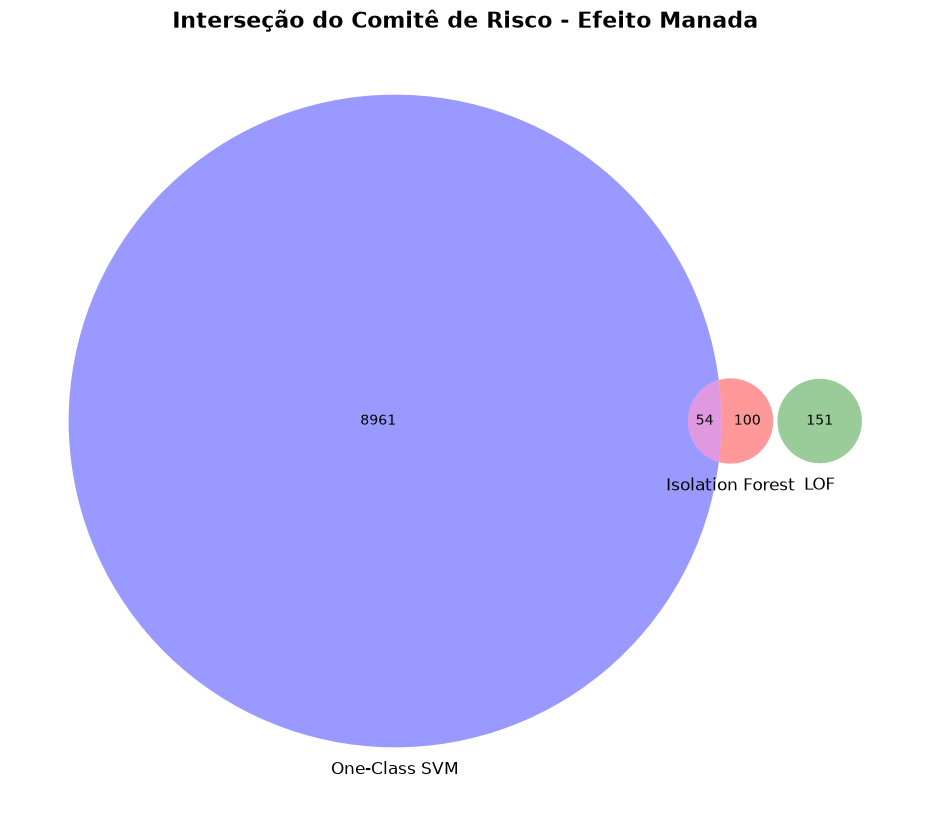

In [50]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# criando um conjunto com cnpj que cada modelo marcou como anôlamo
cnpjs_if = set(df_manada[df_manada['Previsao_if'] == -1].index)
cnpjs_lof = set(df_manada[df_manada['Previsao_lof'] == -1].index)
cnpjs_svm = set(df_manada[df_manada['Previsao_svm'] == -1].index)

plt.figure(figsize=(12, 10))

vd = venn3([cnpjs_if, cnpjs_lof, cnpjs_svm],
           set_labels=('Isolation Forest', 'LOF', 'One-Class SVM'))

plt.title("Interseção do Comitê de Risco - Efeito Manada",
          fontsize=16,
          fontweight='bold')
plt.show()

## Risco de contágio

In [51]:
modelo_if_cont = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
modelo_lof_cont = LocalOutlierFactor(contamination=0.01, n_neighbors=20)    
modelo_svm_cont = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')

df_contagio['Previsao_if'] = modelo_if_cont.fit_predict(df_contagio)
df_contagio['Previsao_lof'] = modelo_lof_cont.fit_predict(df_contagio)
df_contagio['Previsao_svm'] = modelo_svm_cont.fit_predict(df_contagio)

In [52]:
df_contagio['Votos_anomalia'] = (df_contagio[['Previsao_if', 'Previsao_lof', 'Previsao_svm']] == -1).sum(axis=1)

df_voto_absoluto_cont = df_contagio[df_contagio['Votos_anomalia'] == 3]
df_voto_maioria_cont = df_contagio[df_contagio['Votos_anomalia'] >= 2]

df_contagio['Votos_anomalia_if_lof'] = (df_contagio[['Previsao_if', 'Previsao_lof']] == -1).sum(axis=1)
df_voto_if_lof_cont = df_contagio[df_contagio['Votos_anomalia_if_lof'] == 2]

df_contagio['Votos_anomalia_if_svm'] = (df_contagio[['Previsao_if', 'Previsao_svm']] == -1).sum(axis=1)
df_voto_if_svm_cont = df_contagio[df_contagio['Votos_anomalia_if_svm'] == 2]

df_contagio['Votos_anomalia_lof_svm'] = (df_contagio[['Previsao_lof', 'Previsao_svm']] == -1).sum(axis=1)
df_voto_lof_svm_cont = df_contagio[df_contagio['Votos_anomalia_lof_svm'] == 2]

votos_lof = (df_contagio['Previsao_lof'] == -1).sum()
votos_if = (df_contagio['Previsao_if'] == -1).sum()
votos_svm = (df_contagio['Previsao_svm'] == -1).sum()

print(f'Quantidade de votos absolutos: {len(df_voto_absoluto_cont)}')
print(f'Quantidade de votos maioria: {len(df_voto_maioria_cont)}')
print(f'Anomalias validadas por IF e LOF: {len(df_voto_if_lof_cont)}')
print(f'Anomalias validadas por IF e SVM: {len(df_voto_if_svm_cont)}')
print(f'Anomalias validadas por LOF e SVM: {len(df_voto_lof_svm_cont)}')
print(f'Anomalias validadas apenas por IF: {votos_if}')
print(f'Anomalias validadas apenas por LOF: {votos_lof}')
print(f'Anomalias validadas apenas por SVM: {votos_svm}')

Quantidade de votos absolutos: 0
Quantidade de votos maioria: 174
Anomalias validadas por IF e LOF: 0
Anomalias validadas por IF e SVM: 174
Anomalias validadas por LOF e SVM: 0
Anomalias validadas apenas por IF: 244
Anomalias validadas apenas por LOF: 244
Anomalias validadas apenas por SVM: 18661


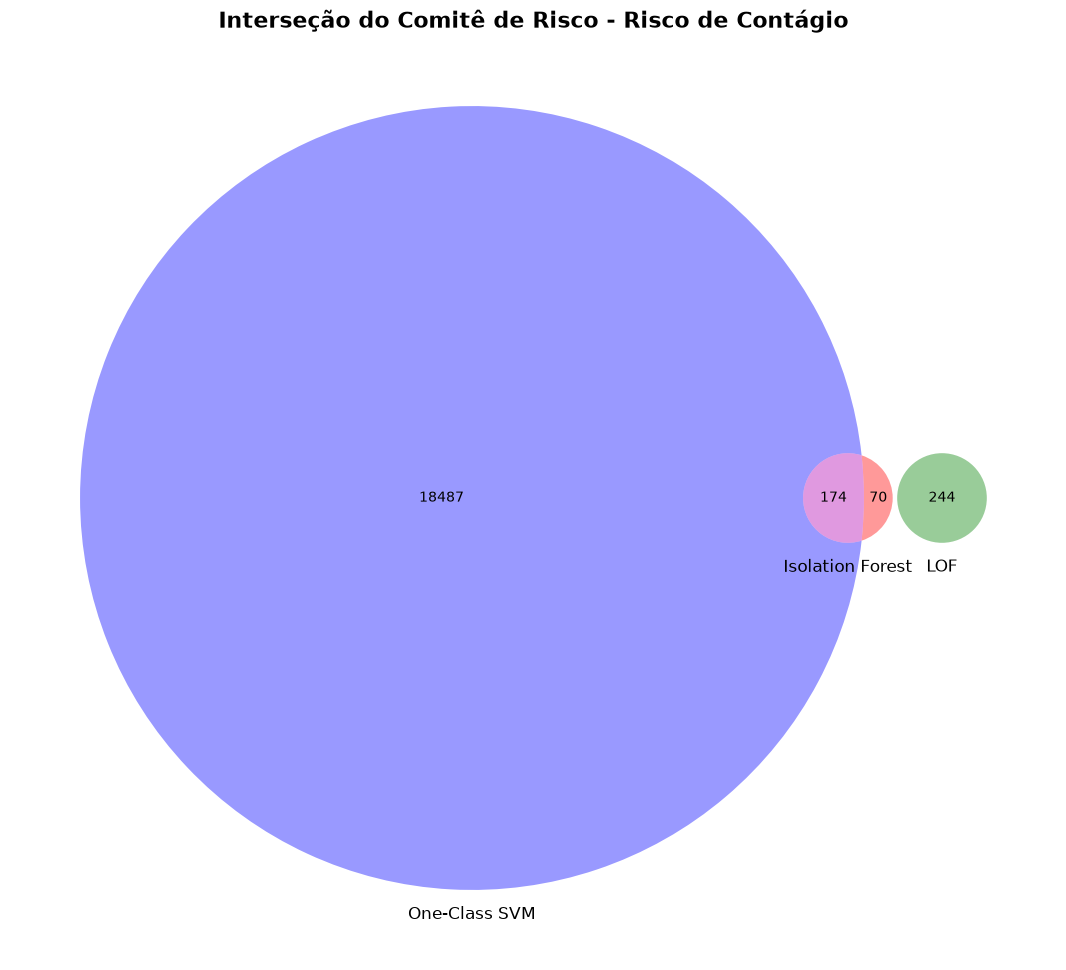

In [53]:
cnpjs_if = set(df_contagio[df_contagio['Previsao_if'] == -1].index)
cnpjs_lof = set(df_contagio[df_contagio['Previsao_lof'] == -1].index)
cnpjs_svm = set(df_contagio[df_contagio['Previsao_svm'] == -1].index)

plt.figure(figsize=(140, 12))

vd = venn3([cnpjs_if, cnpjs_lof, cnpjs_svm],
           set_labels=('Isolation Forest', 'LOF', 'One-Class SVM'))

plt.title("Interseção do Comitê de Risco - Risco de Contágio",
          fontsize=16,
          fontweight='bold')
plt.show()

### Exemplo de Strategy Drift (Mudança abrupta de estratégia de um fundo)

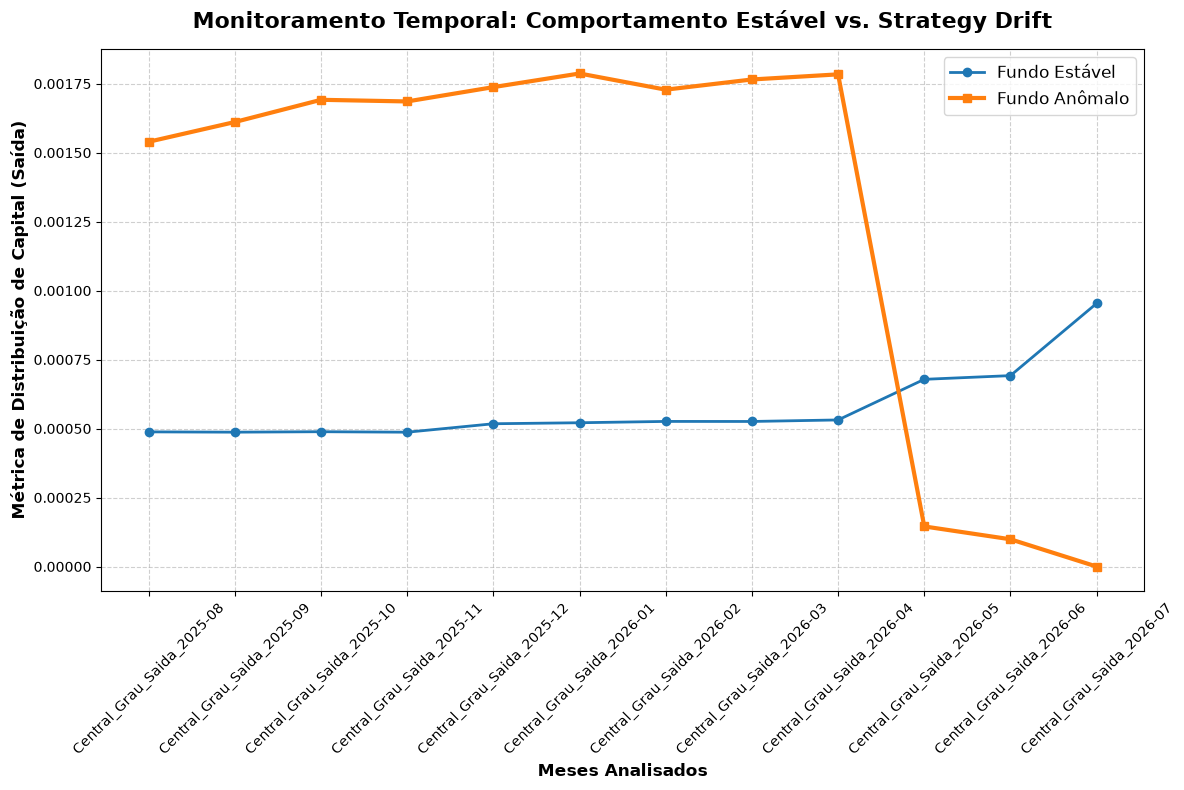

In [54]:
colunas_meses = df_contagio.columns[:12]

fundo_normal = df_contagio[df_contagio['Votos_anomalia'] == 0].iloc[0][colunas_meses]
fundo_anomalo = df_contagio[df_contagio['Votos_anomalia'] >= 2].iloc[0][colunas_meses]

plt.figure(figsize=(12, 8))

plt.plot(colunas_meses, fundo_normal, marker='o', linewidth=2, label='Fundo Estável')
plt.plot(colunas_meses, fundo_anomalo, marker='s', linewidth=3, label='Fundo Anômalo')

plt.title('Monitoramento Temporal: Comportamento Estável vs. Strategy Drift', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Meses Analisados', fontsize=12, fontweight='bold')
plt.ylabel('Métrica de Distribuição de Capital (Saída)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

### Comparação dos fundos marcados anômalos (LOF X SVM X IF)

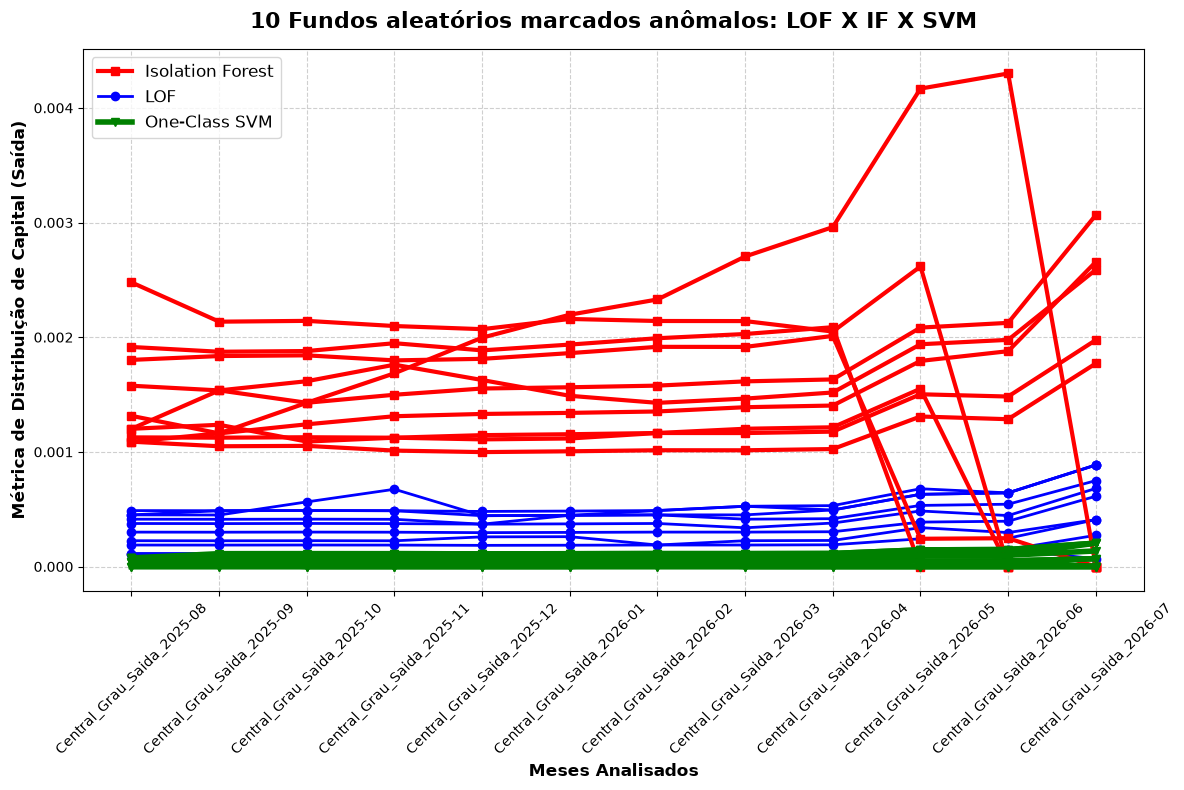

In [55]:
lof_10 = df_contagio[df_contagio['Previsao_lof'] == -1].sample(10)[colunas_meses]
if_10 = df_contagio[df_contagio['Previsao_if'] == -1].sample(10)[colunas_meses]
svm_10 = df_contagio[df_contagio['Previsao_svm'] == -1].sample(10)[colunas_meses]

plt.figure(figsize=(12, 8))

plt.plot(colunas_meses, lof_10.T, marker='o', linewidth=2, color='b')
plt.plot(colunas_meses, if_10.T, marker='s', linewidth=3, color='r')
plt.plot(colunas_meses, svm_10.T, marker='v', linewidth=4, color='g')


plt.title('10 Fundos aleatórios marcados anômalos: LOF X IF X SVM', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Meses Analisados', fontsize=12, fontweight='bold')
plt.ylabel('Métrica de Distribuição de Capital (Saída)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)

import matplotlib.lines as mlines

# Criando os "representantes" para a legenda do artigo
linha_if = mlines.Line2D([], [], color='r', marker='s', linewidth=3, label='Isolation Forest')
linha_lof = mlines.Line2D([], [], color='b', marker='o', linewidth=2, label='LOF')
linha_svm = mlines.Line2D([], [], color='g', marker='v', linewidth=4, label='One-Class SVM')
plt.legend(handles=[linha_if, linha_lof, linha_svm], fontsize=12, loc='upper left')

plt.tight_layout()

In [60]:
df_manada_anomalo = df_manada[df_manada['Votos_Anomalia'] >= 2]
df_manada_anomalo = df_manada_anomalo.reset_index()
df_manada_anomalo.head()

,CNPJ,Central_Grau_Ent_2025-08,Central_Grau_Ent_2025-09,Central_Grau_Ent_2025-10,Central_Grau_Ent_2025-11,Central_Grau_Ent_2025-12,Central_Grau_Ent_2026-01,Central_Grau_Ent_2026-02,Central_Grau_Ent_2026-03,Central_Grau_Ent_2026-04,Central_Grau_Ent_2026-05,Central_Grau_Ent_2026-06,Central_Grau_Ent_2026-07,Previsao_if,Previsao_lof,Previsao_svm,Votos_Anomalia,votos_if_svm,votos_if_lof,votos_lof_svm
0,06.175.696/0001-73,0.017574,0.017460,0.016954,0.016482,0.016896,0.015450,0.016757,0.016076,0.015486,0.013766,0.014334,0.014374,-1,1,-1,2,2,1,1
1,08.418.151/0001-76,0.013143,0.013114,0.013270,0.013074,0.012940,0.013068,0.013188,0.013184,0.013512,0.016868,0.017152,0.017372,-1,1,-1,2,2,1,1
2,08.678.936/0001-88,0.003830,0.003747,0.003722,0.003746,0.003586,0.003574,0.003607,0.003531,0.003416,0.001939,0.001878,0.002384,-1,1,-1,2,2,1,1
3,08.915.927/0001-63,0.039953,0.038930,0.038232,0.038172,0.037267,0.037081,0.035920,0.035907,0.035678,0.027822,0.028768,0.037537,-1,1,-1,2,2,1,1
4,09.215.250/0001-13,0.068717,0.069017,0.068005,0.069639,0.070948,0.071296,0.068382,0.068848,0.066687,0.038825,0.040581,0.000954,-1,1,-1,2,2,1,1


In [64]:
df_ativos = df_fundos_def[['CNPJ_FUNDO_CLASSE_COTA', 'TP_ATIVO', 'NM_FUNDO_CLASSE_SUBCLASSE_COTA']]
df_ativos = df_ativos.rename(columns={'CNPJ_FUNDO_CLASSE_COTA' : 'CNPJ'})
df_ativos.columns

Index(['CNPJ', 'TP_ATIVO', 'NM_FUNDO_CLASSE_SUBCLASSE_COTA'], dtype='str')

In [59]:
df_manada_anomalo.columns

Index(['Central_Grau_Ent_2025-08', 'Central_Grau_Ent_2025-09',
       'Central_Grau_Ent_2025-10', 'Central_Grau_Ent_2025-11',
       'Central_Grau_Ent_2025-12', 'Central_Grau_Ent_2026-01',
       'Central_Grau_Ent_2026-02', 'Central_Grau_Ent_2026-03',
       'Central_Grau_Ent_2026-04', 'Central_Grau_Ent_2026-05',
       'Central_Grau_Ent_2026-06', 'Central_Grau_Ent_2026-07', 'Previsao_if',
       'Previsao_lof', 'Previsao_svm', 'Votos_Anomalia', 'votos_if_svm',
       'votos_if_lof', 'votos_lof_svm'],
      dtype='str')

In [65]:
df_manada_anomalo = pd.merge(df_manada_anomalo, df_ativos, on='CNPJ', how='left')
df_manada_anomalo.head()

,CNPJ,Central_Grau_Ent_2025-08,Central_Grau_Ent_2025-09,Central_Grau_Ent_2025-10,Central_Grau_Ent_2025-11,Central_Grau_Ent_2025-12,Central_Grau_Ent_2026-01,Central_Grau_Ent_2026-02,Central_Grau_Ent_2026-03,Central_Grau_Ent_2026-04,...,Central_Grau_Ent_2026-07,Previsao_if,Previsao_lof,Previsao_svm,Votos_Anomalia,votos_if_svm,votos_if_lof,votos_lof_svm,TP_ATIVO,NM_FUNDO_CLASSE_SUBCLASSE_COTA
0,06.175.696/0001-73,0.017574,0.01746,0.016954,0.016482,0.016896,0.01545,0.016757,0.016076,0.015486,...,0.014374,-1,1,-1,2,2,1,1,Fundo de Investimento e de Cotas,ITAÚ SOBERANO RENDA FIXA SIMPLES FIF DA CIC RE...
1,06.175.696/0001-73,0.017574,0.01746,0.016954,0.016482,0.016896,0.01545,0.016757,0.016076,0.015486,...,0.014374,-1,1,-1,2,2,1,1,Fundo de Investimento e de Cotas,ITAÚ SOBERANO RENDA FIXA SIMPLES FIF DA CIC RE...
2,06.175.696/0001-73,0.017574,0.01746,0.016954,0.016482,0.016896,0.01545,0.016757,0.016076,0.015486,...,0.014374,-1,1,-1,2,2,1,1,Fundo de Investimento e de Cotas,ITAÚ SOBERANO RENDA FIXA SIMPLES FIF DA CIC RE...
3,06.175.696/0001-73,0.017574,0.01746,0.016954,0.016482,0.016896,0.01545,0.016757,0.016076,0.015486,...,0.014374,-1,1,-1,2,2,1,1,Fundo de Investimento e de Cotas,ITAÚ SOBERANO RENDA FIXA SIMPLES FIF DA CIC RE...
4,06.175.696/0001-73,0.017574,0.01746,0.016954,0.016482,0.016896,0.01545,0.016757,0.016076,0.015486,...,0.014374,-1,1,-1,2,2,1,1,Fundo de Investimento e de Cotas,ITAÚ SOBERANO RENDA FIXA SIMPLES FIF DA CIC RE...


In [ ]:
df_manada_anomalo = df_manada_anomalo.drop_duplicates(subset=['CNPJ'], keep='first')
df_manada_anomalo.shape

(54, 22)

In [76]:
tipo_ativo = df_manada_anomalo['TP_ATIVO'].value_counts()
tipo_ativo

TP_ATIVO
Fundo de Investimento e de Cotas    41
FIDC                                 8
FI Participações                     3
Fundos de Índice                     2
Name: count, dtype: int64

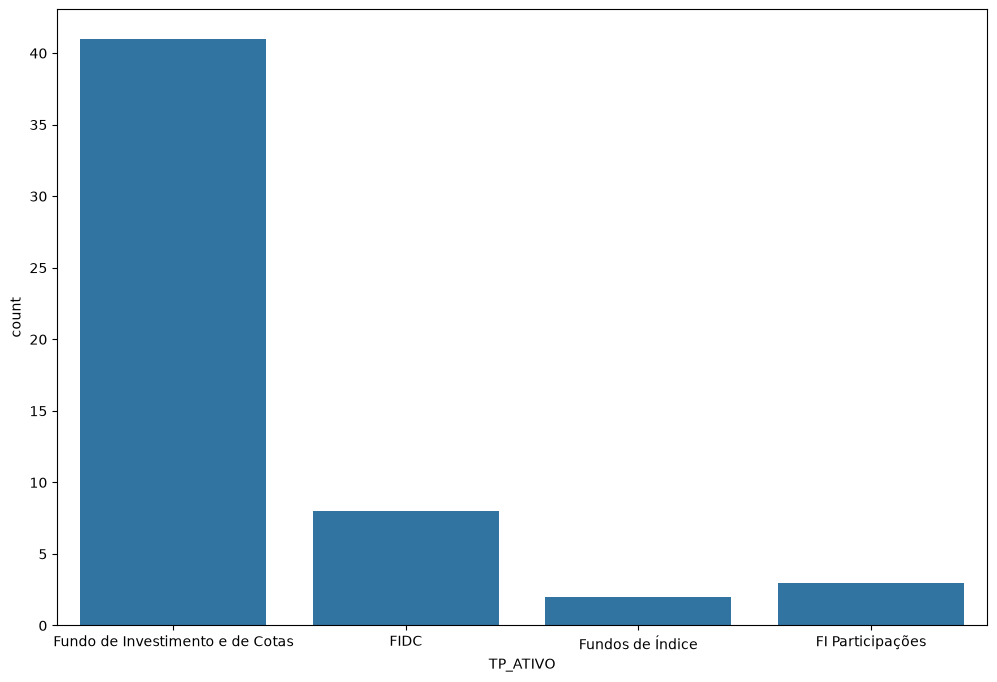

In [81]:
import seaborn as sns

plt.figure(figsize=(12, 8))
# Automatically calculates value counts and plots them
sns.countplot(data=df_manada_anomalo, x='TP_ATIVO')
plt.show()
